In [34]:
# Michele Bianco: 12.04.2025
import numpy as np, random
from scipy.linalg import norm
from tqdm import tqdm

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import astropy.constants as cst

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from utils_rt import refine_grid_2d
from utils_rtplot import plot_irregular_grid_cells, plot_ray

## Define source & target position

In [45]:
# box mesh and cell (physical) size
meshsize = 6
dL = 0.1 * u.cm

# position target cell
#r_target = np.array([5.25, 4.25])
r_target = np.array([4.75, 5.25])
print('target:', r_target)

# source position
r_source = np.array([1.5, 1.5])
#r_source = np.array([0.5, 0.5])
print('source:', r_source)

# vector from source to cells
r_st = r_target - r_source
n_st = r_st/norm(r_st)
print('source to target:', n_st)
print('distance:', norm(r_st))

target: [4.75 5.25]
source: [1.5 1.5]
source to target: [0.65493054 0.75568908]
distance: 4.962358310319802


## Define irregular grid

In [47]:
# define position of the refinde cells
refine_cells = [(3, 3), (3, 4), (4, 3), (4, 4), (5, 3), (5, 4), (3, 5), (4, 5), (5, 5)]

# define level of the refined cells (resolution: 2^levels, similar to Ramses-RT)
levels = {(3, 3): 2, (3, 4): 1, (4, 3): 1, (4, 4): 1, (5, 3): 1, (5, 4): 1, (3, 5): 1, (4, 5): 1, (5, 5): 1}

# Create refined 2D grid (no specific convention)
x_grid, y_grid, dr = refine_grid_2d(meshsize=meshsize, refine_cells=refine_cells, levels=levels)

# Coordinate of each cells (at the center of the cell)
r_c = np.vstack((x_grid, y_grid)).T

# define density grid
ndens = (4e-31 * u.g/u.cm**3) / (cst.m_p+cst.m_e)  / dr

In [43]:
# only rays in the direction of the the target
mask_x = (r_c[:, 0] <= r_target[0]) * (r_c[:, 0] >= r_source[0])
mask_y = (r_c[mask_x, 1] <= r_target[1]) * (r_c[mask_x, 1] >= r_source[1])

# cells position
r_cell = r_c[mask_x][mask_y]
dr_grid = dr[mask_x][mask_y]

print(r_cell.shape)

(44, 2)


## Calculate which cells cross the ray

https://en.wikipedia.org/wiki/Line%E2%80%93plane_intersection

In [28]:
# source to cells vector
r_sc = r_cell - r_source

# lenght by dot product
l = r_sc.dot(n_st)

# closest point on the tangent to the cells 
r_p = r_source + l[:,None]*n_st[None,:]

# point onto tanget to cell vector
r_cp = r_p - r_cell

# select only the cell that are touched by the ray
mask = np.array([(np.abs(r_cp[i,0]) <= dr_grid[i]/2) and (np.abs(r_cp[i,1]) <= dr_grid[i]/2) for i in range(dr_grid.size)])

r_touch = r_cell[mask]
dr_touch = dr_grid[mask]

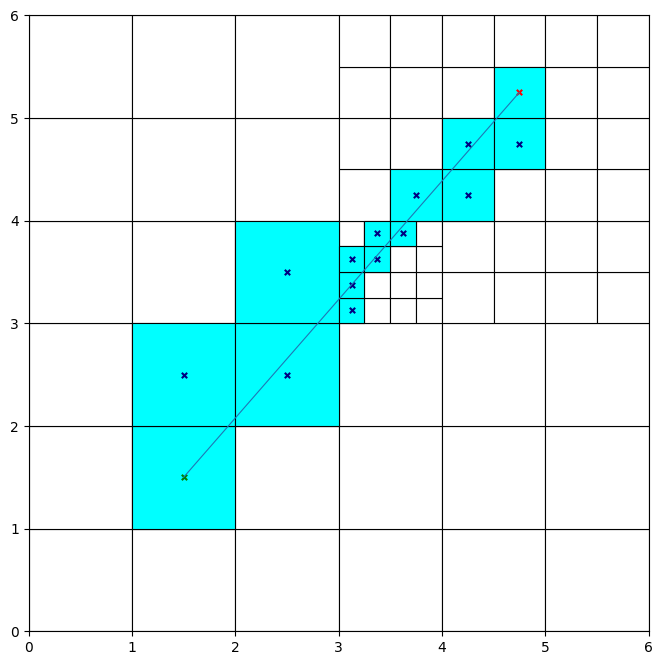

In [29]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_c, dr=dr, ax=ax)

# plot cells that are touched by the ray
plot_irregular_grid_cells(r_c=r_touch, dr=dr_touch, color='cyan', ax=ax)

# mark cells that are crossed by the ray
ax.scatter(x=r_touch[1:-1,0], y=r_touch[1:-1,1], s=15, marker='x', color='navy', label='target')

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')

ax.set_xlim(0, meshsize)
ax.set_ylim(0, meshsize)
plt.show()

The blue cells here are the one we need to look at and apply the raytracing algorithm. Loop on them to find the corresponding column density.

In [7]:
for i in range(r_touch.shape[0]):
    print(r_touch[i], r_touch[i] + dr_touch[i]/2)

[1.5 1.5] [2. 2.]
[2.5 1.5] [3. 2.]
[2.5 2.5] [3. 3.]
[3.5 2.5] [4. 3.]
[3.625 3.125] [3.75 3.25]
[3.875 3.125] [4.   3.25]
[3.875 3.375] [4.  3.5]
[4.25 3.25] [4.5 3.5]
[4.25 3.75] [4.5 4. ]
[4.75 3.75] [5. 4.]
[4.75 4.25] [5.  4.5]
[5.25 4.25] [5.5 4.5]


## Long Charateristic Raytracing

In [8]:
# previous point of interception (init is source position)
r_inter = np.zeros_like(r_touch)
dist = np.zeros(r_touch.shape[0])
dist_prev = 0

for idx in range(r_touch.shape[0]):  
    # vector to the source to the plane
    r_isp = np.array([dr_touch[idx]/2, 0.])
    r_jsp = np.array([0., dr_touch[idx]/2])
    #print(r_isp, r_jsp)
    
    # point on the plane
    p_i0 = r_touch[idx] + r_isp
    p_j0 = r_touch[idx] + r_jsp
    
    # normal vector to the surf
    n_iplan = r_isp/norm(r_isp)
    n_jplan = r_jsp/norm(r_jsp)

    # parametric distance of the plan
    d_i = (p_i0-r_source).dot(n_iplan)/(n_st.dot(n_iplan))
    d_j = (p_j0-r_source).dot(n_jplan)/(n_st.dot(n_jplan))
    
    # id of the cell (use this to get the corresponding density)
    if(d_i < d_j):
        r_inter[idx] = r_source + d_i*n_st
        dist[idx] = d_i - dist_prev
        dist_prev = d_i
    else:
        r_inter[idx] = r_source + d_j*n_st
        dist[idx] = d_j - dist_prev
        dist_prev = d_j

# the last cell it stops to the cells coordinate center
r_inter[-1] = r_touch[-1]

# the distance to the last cell is half that value
dist[-1] = dist[-1]/2

print(dist, dist.size)

[0.62003584 0.22546758 1.0146041  0.67640274 0.25365103 0.16910068
 0.14091724 0.28183447 0.33820137 0.50730205 0.11273379 0.31001792] 12


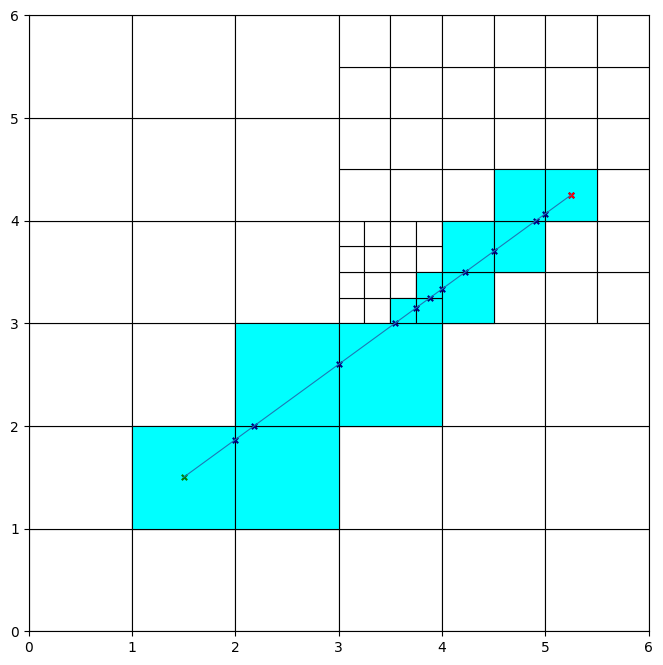

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

# plot grid with cell boundaries and refinement
plot_irregular_grid_cells(r_c=r_c, dr=dr, ax=ax)

# plot cells that are touched by the ray
plot_irregular_grid_cells(r_c=r_touch, dr=dr_touch, color='cyan', ax=ax)

# plot ray
x_plot, y_plot = plot_ray(r_s=r_source, r_t=r_target)
ax.plot(x_plot, y_plot, lw=0.8, label='ray')

# plot target and source
ax.scatter(x=r_inter[:,0], y=r_inter[:,1], s=15, marker='x', color='navy', label='interception')
ax.scatter(x=r_source[0], y=r_source[1], s=15, marker='x', color='green', label='source')
ax.scatter(x=r_target[0], y=r_target[1], s=15, marker='x', color='red', label='target')

ax.set_xlim(0, meshsize)
ax.set_ylim(0, meshsize)
plt.show()

In [58]:
np.sum(dist*dL * ndens[mask_x][mask_y][mask])

ValueError: operands could not be broadcast together with shapes (12,) (15,) 

In [62]:
ndens[mask_x][mask_y][mask]

<Quantity [0.00023902, 0.00023902, 0.00023902, 0.00023902, 0.00095606,
           0.00095606, 0.00095606, 0.00095606, 0.00095606, 0.00095606,
           0.00047803, 0.00047803, 0.00047803, 0.00047803, 0.00047803] g / (kg cm3)>

In [64]:
(dist*dL).size

12